In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("../data/raw/nba_stats.csv")
df.head()

,Player,Tm,Opp,Result,MP,FG,FGA,FG%,3P,3PA,...,BLK,TOV,PF,PTS,+/-,GmSc,Date,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Luka Dončić,LAL,GSW,L,40:59,17.0,27.0,0.630,2.0,10.0,...,1.0,3.0,1.0,43.0,-8.0,38.9,2025-10-21,NaN,NaN,NaN
1,Alperen Şengün,HOU,OKC,L,48:53,12.0,24.0,0.500,5.0,8.0,...,1.0,4.0,5.0,39.0,9.0,33.1,2025-10-21,NaN,NaN,NaN
2,Jimmy Butler,GSW,LAL,W,34:44,7.0,14.0,0.500,1.0,2.0,...,0.0,1.0,4.0,31.0,20.0,27.5,2025-10-21,NaN,NaN,NaN
3,Shai Gilgeous-Alexander,OKC,HOU,W,47:13,12.0,26.0,0.462,1.0,9.0,...,2.0,3.0,2.0,35.0,3.0,24.6,2025-10-21,NaN,NaN,NaN
4,Austin Reaves,LAL,GSW,L,36:20,9.0,16.0,0.563,1.0,5.0,...,0.0,5.0,5.0,26.0,-14.0,20.4,2025-10-21,NaN,NaN,NaN


In [3]:
df.shape


(28716, 29)

In [4]:
df.columns

Index(['Player', 'Tm', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date', 'Unnamed: 0', 'Unnamed: 1',
       'Unnamed: 2'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28716 entries, 0 to 28715
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      28716 non-null  object 
 1   Tm          28716 non-null  object 
 2   Opp         28716 non-null  object 
 3   Result      28716 non-null  object 
 4   MP          28716 non-null  object 
 5   FG          28716 non-null  float64
 6   FGA         28716 non-null  float64
 7   FG%         27206 non-null  float64
 8   3P          28716 non-null  float64
 9   3PA         28716 non-null  float64
 10  3P%         22941 non-null  float64
 11  FT          28716 non-null  float64
 12  FTA         28716 non-null  float64
 13  FT%         16030 non-null  float64
 14  ORB         28716 non-null  float64
 15  DRB         28716 non-null  float64
 16  TRB         28716 non-null  float64
 17  AST         28716 non-null  float64
 18  STL         28716 non-null  float64
 19  BLK         28716 non-nul

In [6]:
df.describe()

,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,...,STL,BLK,TOV,PF,PTS,+/-,GmSc,Unnamed: 0,Unnamed: 1,Unnamed: 2
count,28716.000000,28716.000000,27206.000000,28716.000000,28716.000000,22941.000000,28716.000000,28716.000000,16030.000000,28716.000000,...,28716.000000,28716.000000,28716.000000,28716.000000,28716.000000,28686.00000,28716.000000,0.0,0.0,0.0
mean,3.842388,8.179273,0.459133,1.216674,3.390201,0.331980,1.696406,2.169383,0.767805,1.046594,...,0.772844,0.447799,1.268143,1.842771,10.597855,0.00000,8.635148,NaN,NaN,NaN
std,3.163977,5.856687,0.238915,1.481276,3.021536,0.285104,2.387845,2.857715,0.279390,1.380616,...,0.992910,0.812679,1.397459,1.467710,8.675463,11.92564,7.701729,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-60.00000,-10.200000,NaN,NaN,NaN
25%,1.000000,4.000000,0.333000,0.000000,1.000000,0.000000,0.000000,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,1.000000,4.000000,-7.00000,2.500000,NaN,NaN,NaN
50%,3.000000,7.000000,0.471000,1.000000,3.000000,0.333000,1.000000,2.000000,0.846000,1.000000,...,0.000000,0.000000,1.000000,2.000000,9.000000,0.00000,7.300000,NaN,NaN,NaN
75%,6.000000,12.000000,0.600000,2.000000,5.000000,0.500000,2.000000,3.000000,1.000000,2.000000,...,1.000000,1.000000,2.000000,3.000000,16.000000,7.00000,13.300000,NaN,NaN,NaN
max,20.000000,45.000000,1.000000,12.000000,22.000000,1.000000,36.000000,43.000000,1.000000,13.000000,...,8.000000,12.000000,11.000000,6.000000,83.000000,52.00000,60.500000,NaN,NaN,NaN


In [7]:
df.isnull().sum()

Player            0
Tm                0
Opp               0
Result            0
MP                0
FG                0
FGA               0
FG%            1510
3P                0
3PA               0
3P%            5775
FT                0
FTA               0
FT%           12686
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              30
GmSc              0
Date              0
Unnamed: 0    28716
Unnamed: 1    28716
Unnamed: 2    28716
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Player         object
Tm             object
Opp            object
Result         object
MP             object
FG            float64
FGA           float64
FG%           float64
3P            float64
3PA           float64
3P%           float64
FT            float64
FTA           float64
FT%           float64
ORB           float64
DRB           float64
TRB           float64
AST           float64
STL           float64
BLK           float64
TOV           float64
PF            float64
PTS           float64
+/-           float64
GmSc          float64
Date           object
Unnamed: 0    float64
Unnamed: 1    float64
Unnamed: 2    float64
dtype: object

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

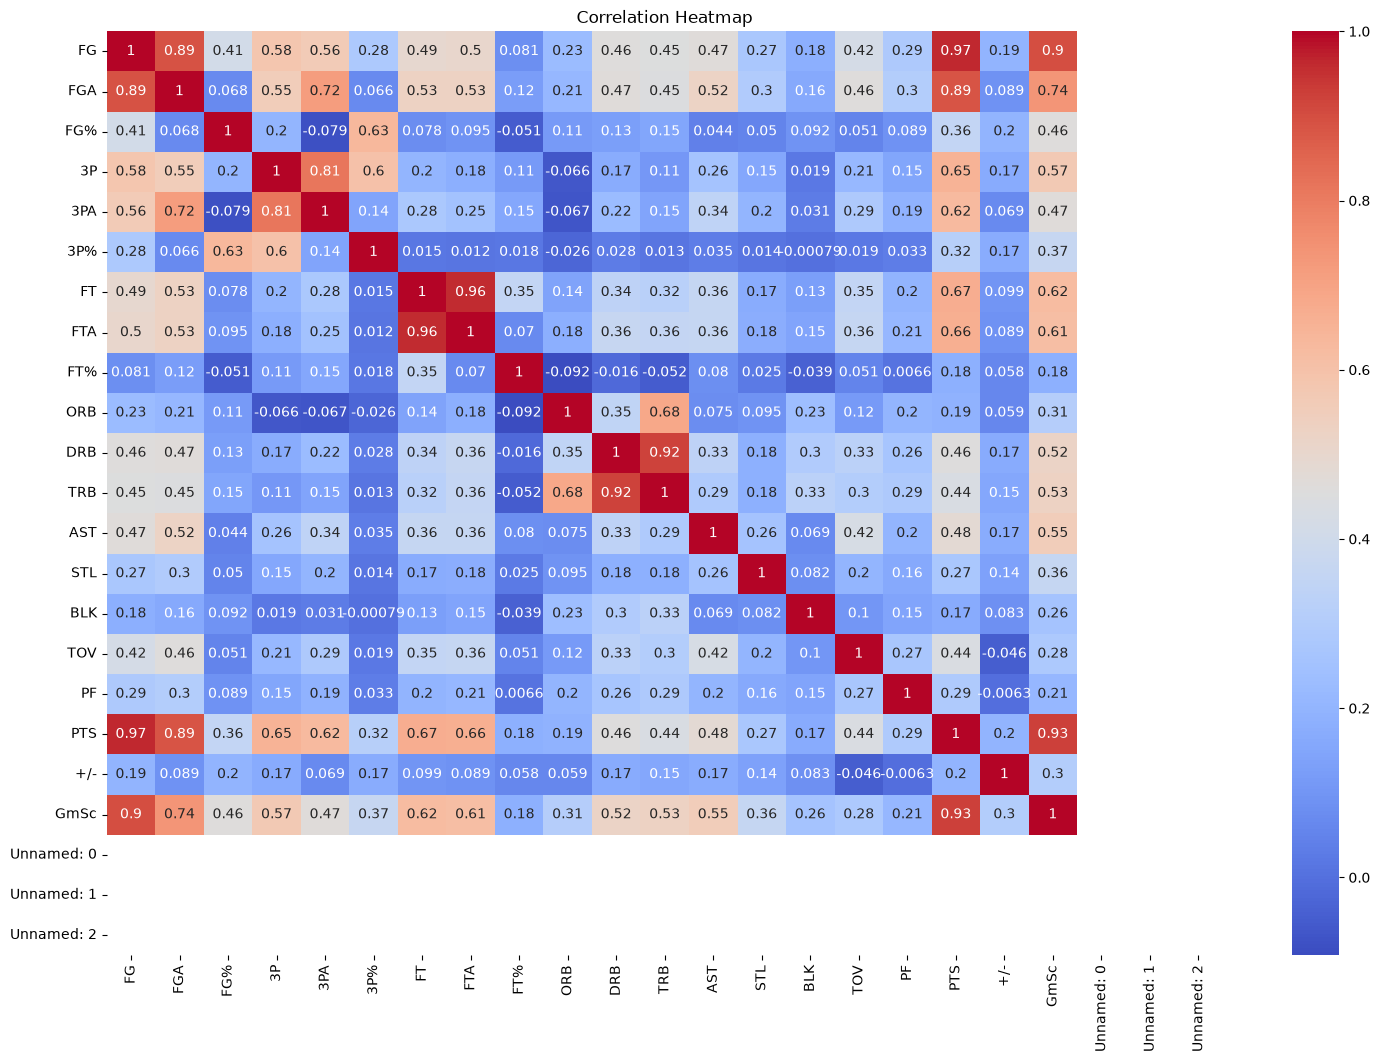

In [11]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

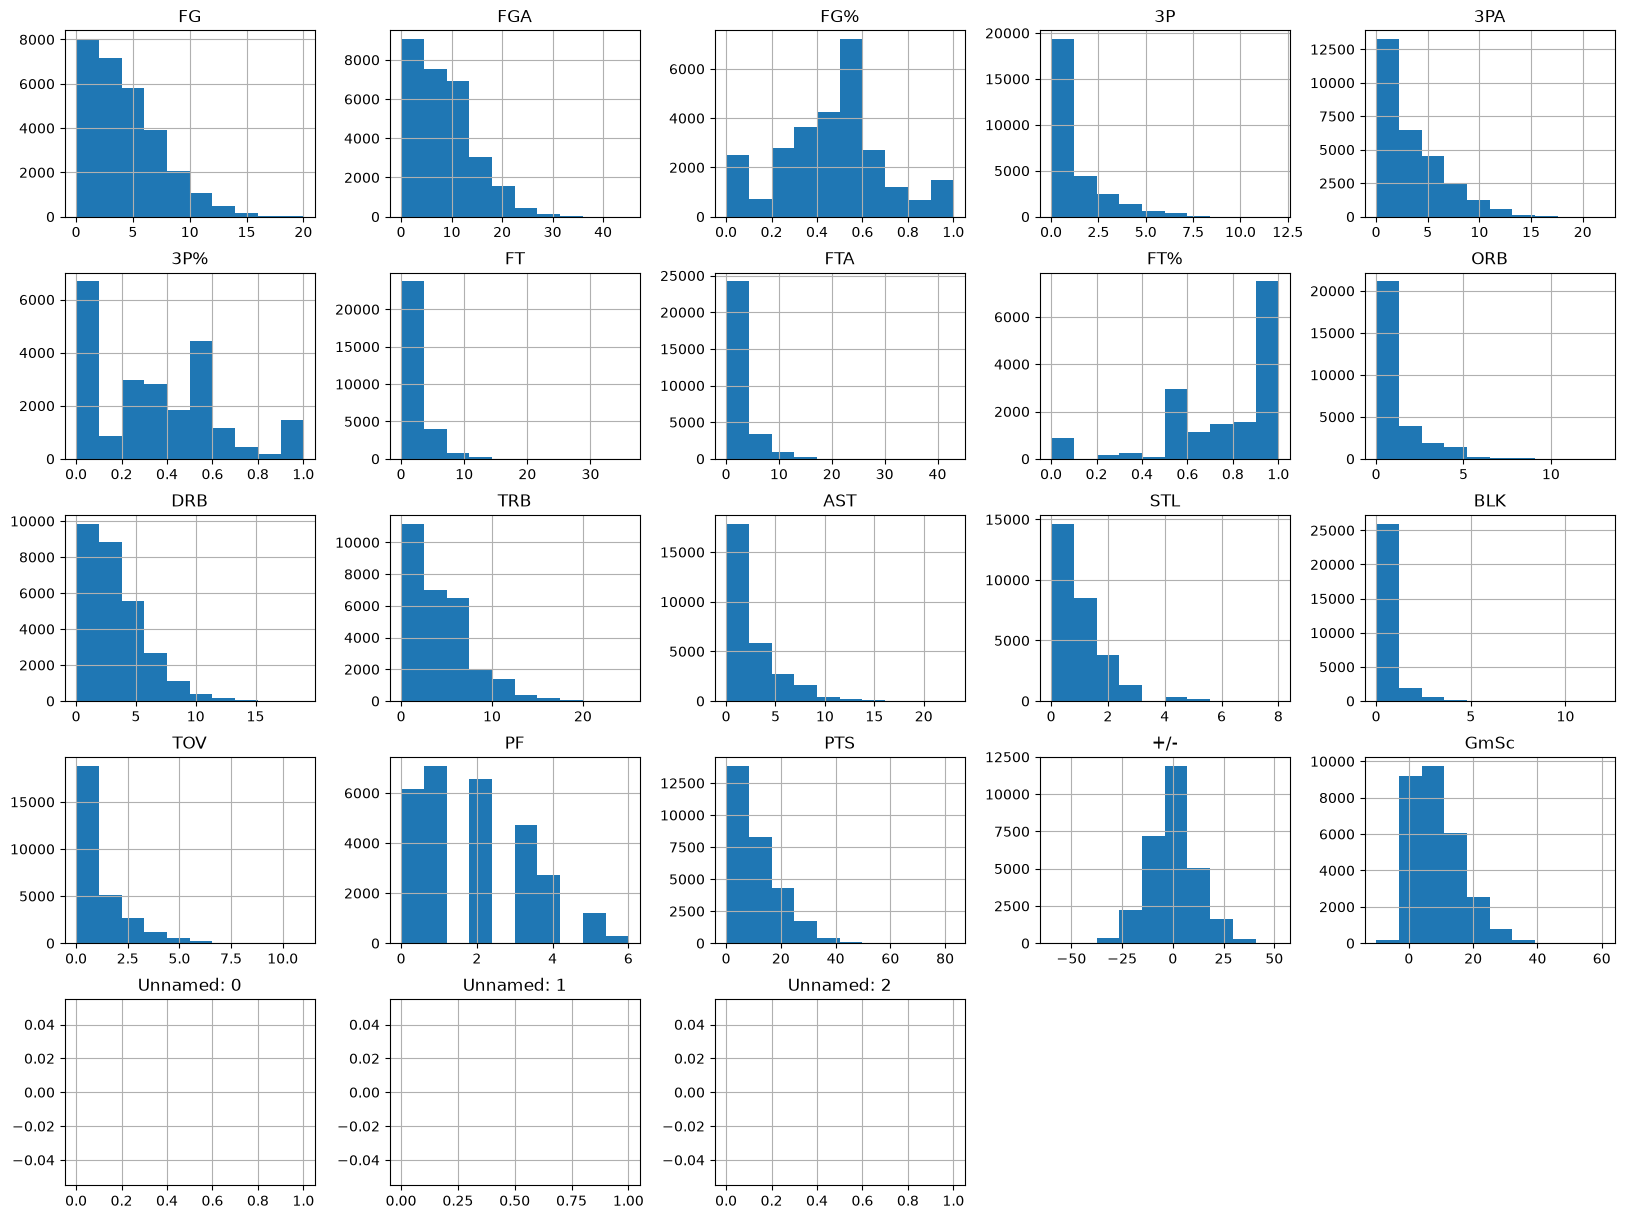

In [12]:
df.hist(figsize=(20,15))

plt.show()

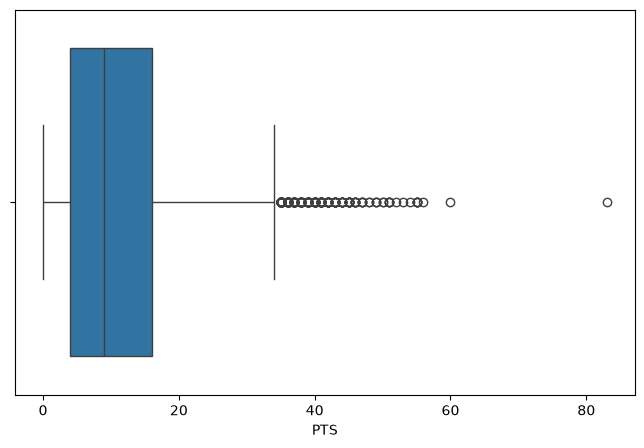

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["PTS"])

plt.show()

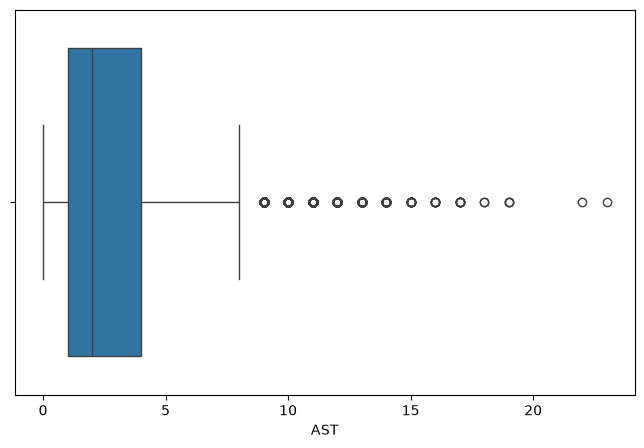

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["AST"])

plt.show()

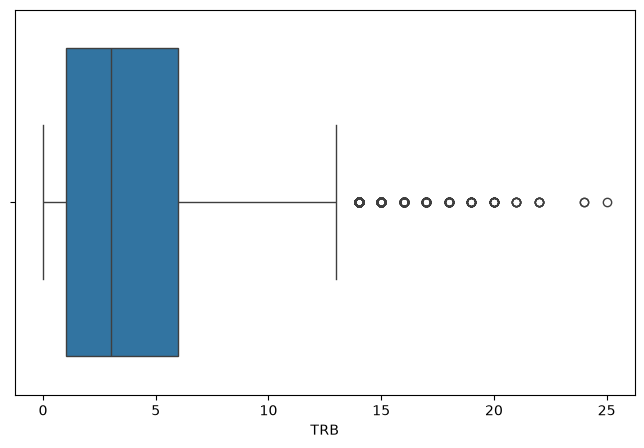

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["TRB"])

plt.show()

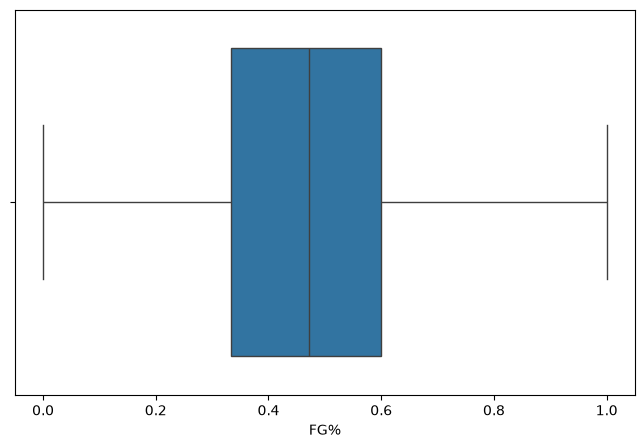

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["FG%"])

plt.show()

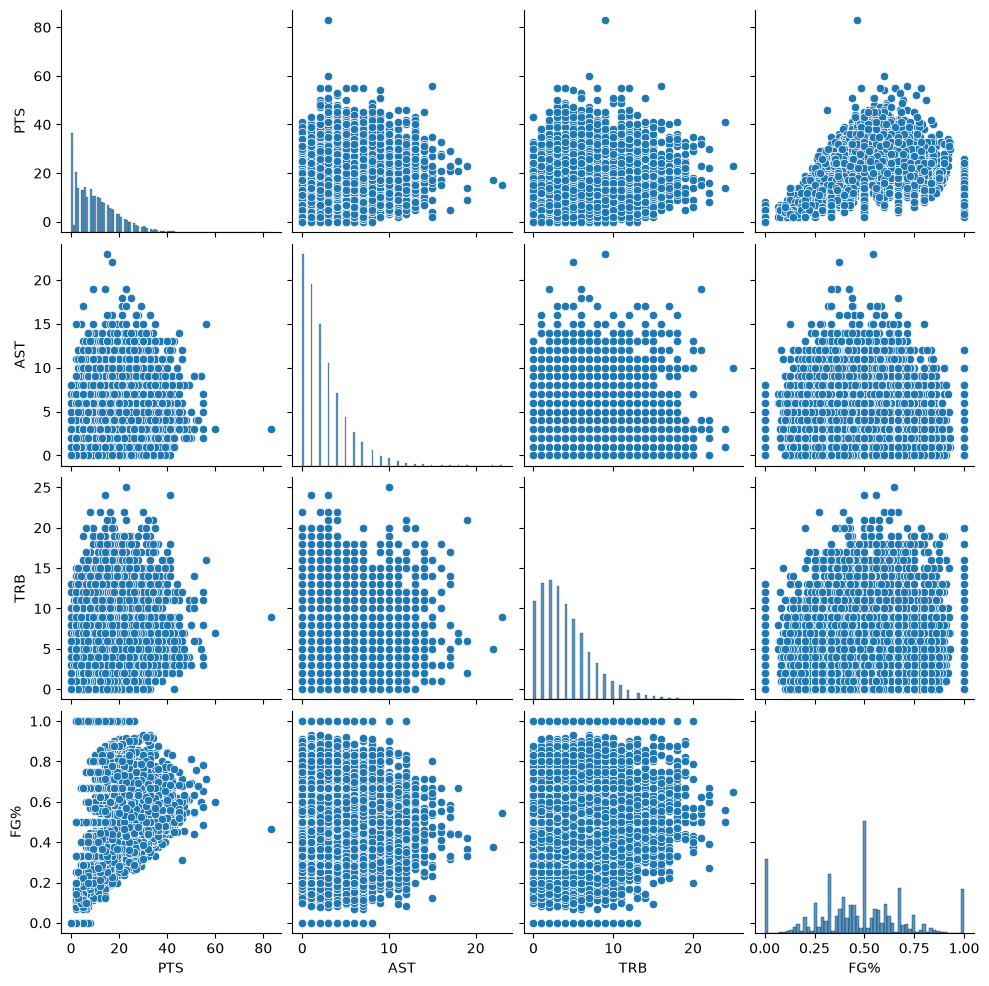

In [17]:
sns.pairplot(
    df[["PTS","AST","TRB","FG%"]]
)

In [18]:
df.shape

(28716, 29)

In [19]:
df.columns


Index(['Player', 'Tm', 'Opp', 'Result', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', '+/-', 'GmSc', 'Date', 'Unnamed: 0', 'Unnamed: 1',
       'Unnamed: 2'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28716 entries, 0 to 28715
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Player      28716 non-null  object 
 1   Tm          28716 non-null  object 
 2   Opp         28716 non-null  object 
 3   Result      28716 non-null  object 
 4   MP          28716 non-null  object 
 5   FG          28716 non-null  float64
 6   FGA         28716 non-null  float64
 7   FG%         27206 non-null  float64
 8   3P          28716 non-null  float64
 9   3PA         28716 non-null  float64
 10  3P%         22941 non-null  float64
 11  FT          28716 non-null  float64
 12  FTA         28716 non-null  float64
 13  FT%         16030 non-null  float64
 14  ORB         28716 non-null  float64
 15  DRB         28716 non-null  float64
 16  TRB         28716 non-null  float64
 17  AST         28716 non-null  float64
 18  STL         28716 non-null  float64
 19  BLK         28716 non-nul

In [21]:
df.isnull().sum()

Player            0
Tm                0
Opp               0
Result            0
MP                0
FG                0
FGA               0
FG%            1510
3P                0
3PA               0
3P%            5775
FT                0
FTA               0
FT%           12686
ORB               0
DRB               0
TRB               0
AST               0
STL               0
BLK               0
TOV               0
PF                0
PTS               0
+/-              30
GmSc              0
Date              0
Unnamed: 0    28716
Unnamed: 1    28716
Unnamed: 2    28716
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

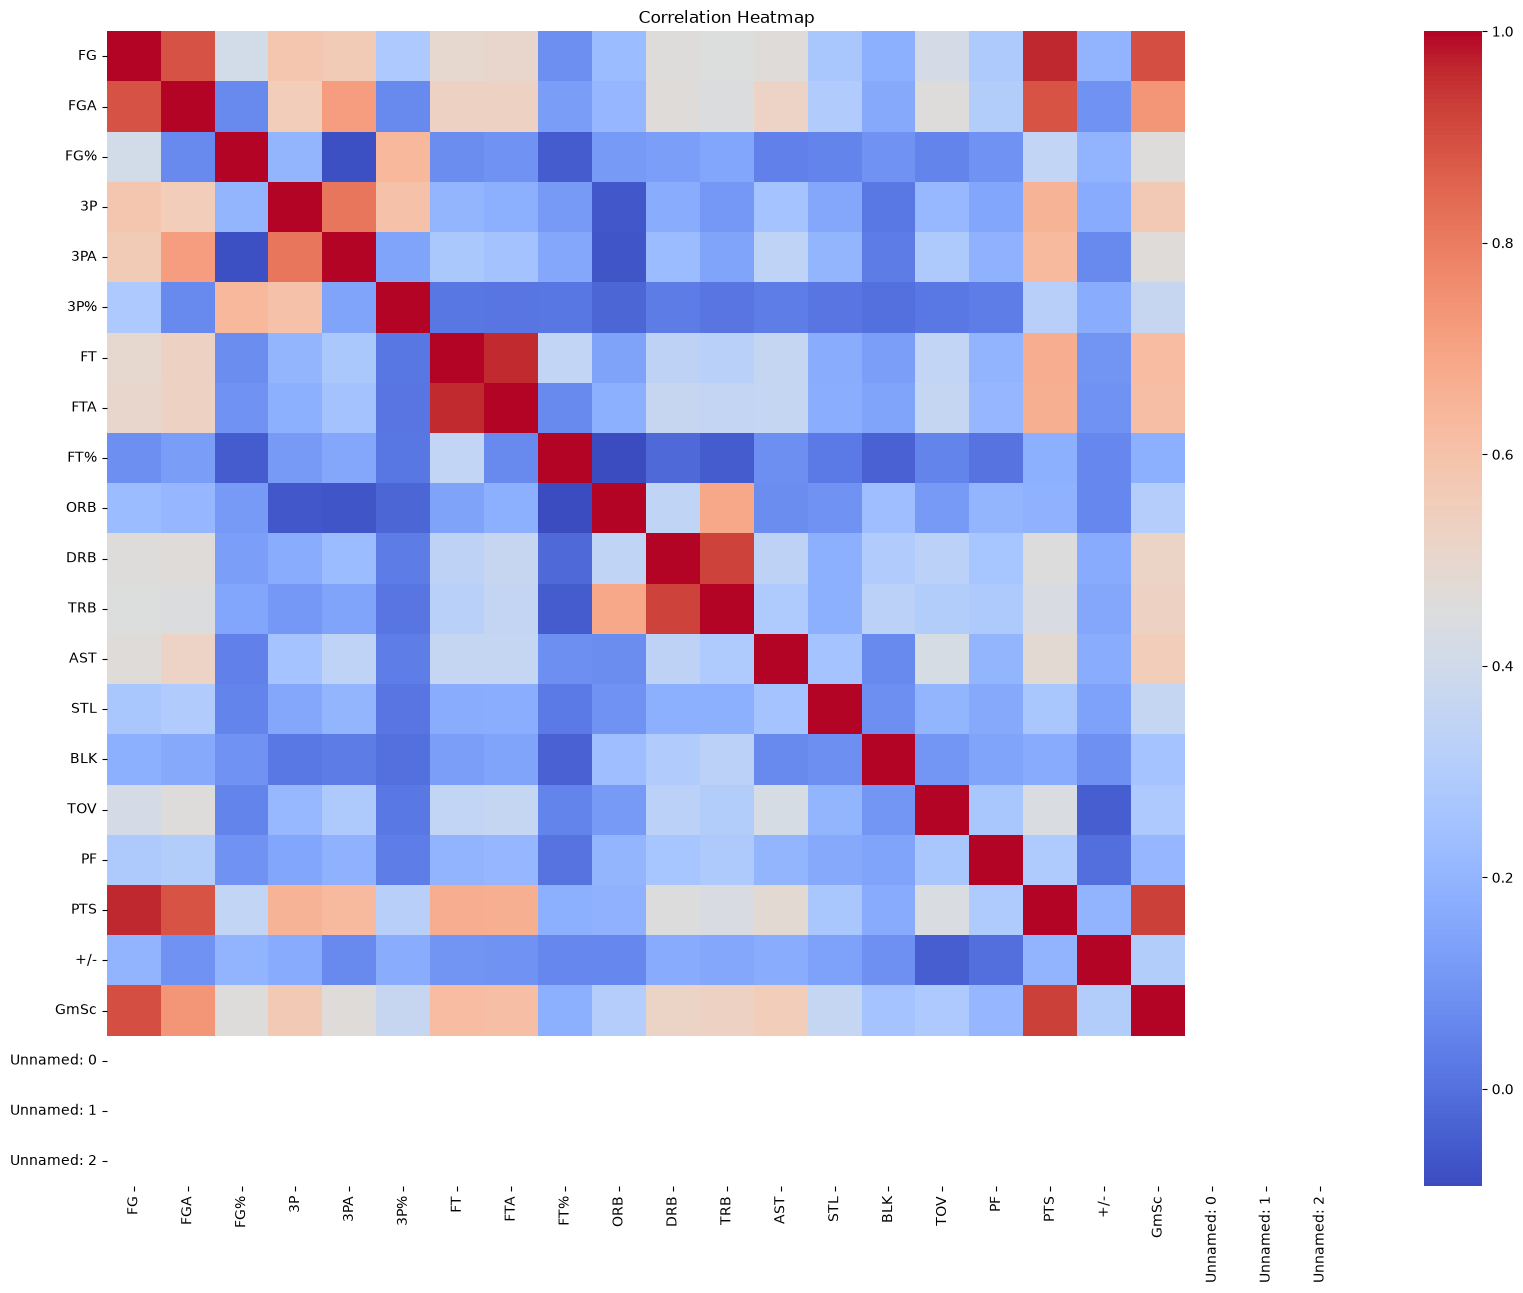

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

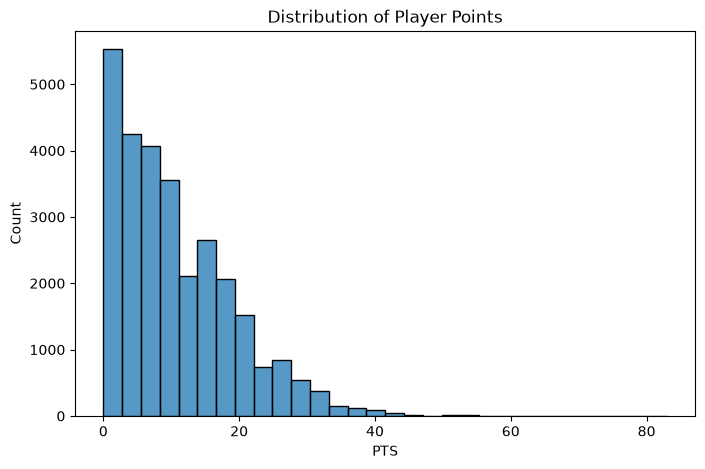

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["PTS"], bins=30)

plt.title("Distribution of Player Points")

plt.show()

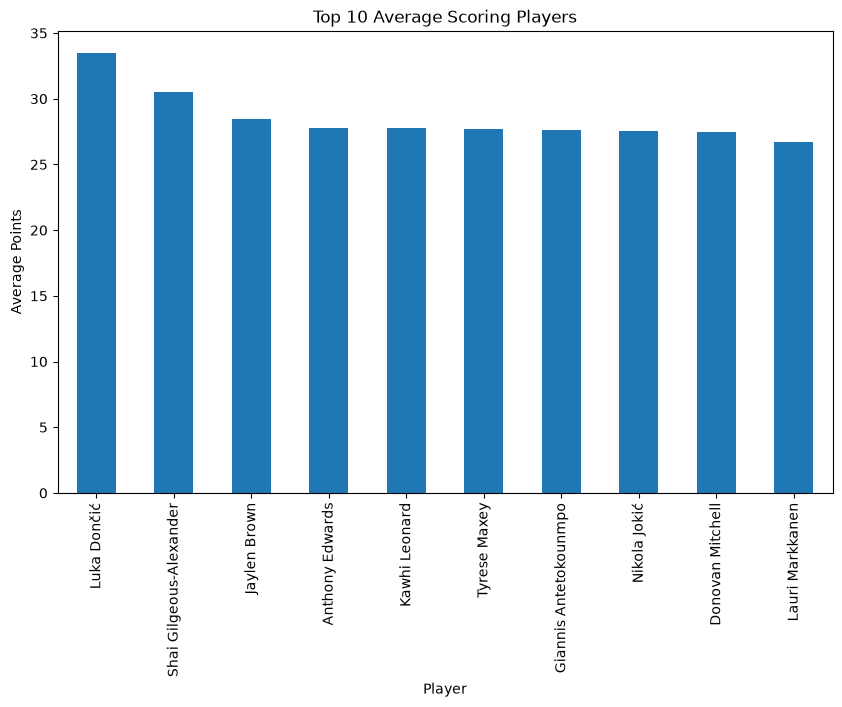

In [25]:
top_players = (
    df.groupby("Player")["PTS"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

top_players.plot(kind="bar")

plt.title("Top 10 Average Scoring Players")

plt.ylabel("Average Points")

plt.show()

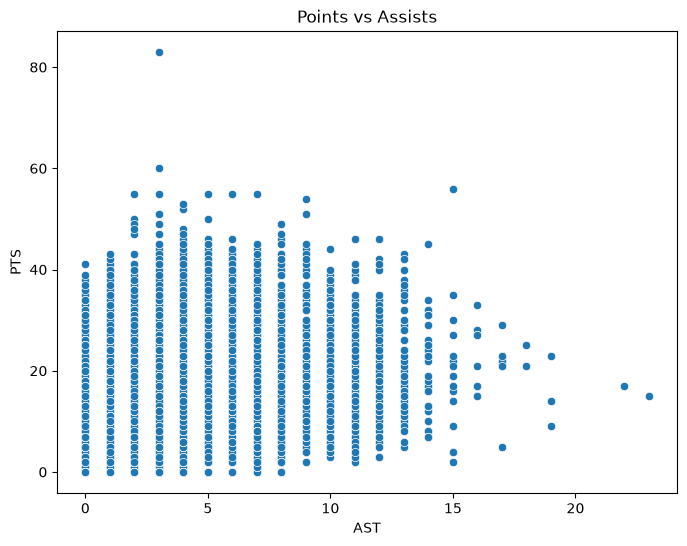

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AST",
    y="PTS"
)

plt.title("Points vs Assists")

plt.show()

In [27]:
def convert_minutes(mp):
    minutes, seconds = mp.split(":")
    return int(minutes) + int(seconds) / 60

df["MP"] = df["MP"].apply(convert_minutes)

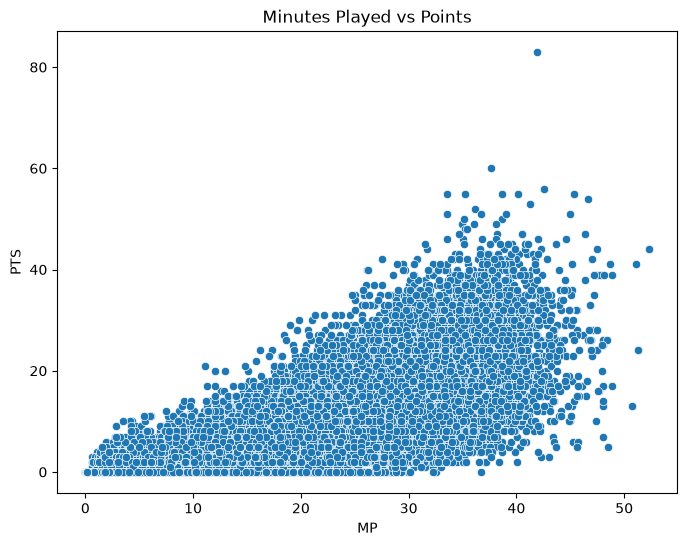

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="MP",
    y="PTS"
)

plt.title("Minutes Played vs Points")

plt.show()

In [31]:
df.columns.tolist()

['Player',
 'Tm',
 'Opp',
 'Result',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 '+/-',
 'GmSc',
 'Date',
 'Unnamed: 0',
 'Unnamed: 1',
 'Unnamed: 2']